<a href="https://colab.research.google.com/github/nathan-paolangeli/fractal-analysis-research/blob/main/MSCI_Frontier_Markets_Fractal_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nolds

In [ ]:
import nolds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Chaos and Fractals/frontiermarkets.csv')

In [ ]:
df['Return'] = df['Values'].pct_change()
data_raw = df['Return']
data_raw_price = df['Values']
nan_mask = pd.isna(data_raw)
nan_mask_price = pd.isna(data_raw_price)
data_price = data_raw_price[~nan_mask_price]
data = data_raw[~nan_mask]
print(data)

1      0.022864
2     -0.015287
3      0.033962
4     -0.034072
5      0.008388
         ...   
258    0.071109
259    0.030453
260    0.009987
261    0.000562
262    0.041521
Name: Return, Length: 262, dtype: float64


In [ ]:
def rs(data, n, unbiased=True):
  data = np.asarray(data)
  total_N = len(data)
  m = total_N // n # number of sequences
  # cut values at the end of data to make the array divisible by n
  data = data[:total_N - (total_N % n)]
  # split remaining data into subsequences of length n
  seqs = np.reshape(data, (m, n))
  # calculate means of subsequences
  means = np.mean(seqs, axis=1)
  # normalize subsequences by substracting mean
  y = seqs - means.reshape((m, 1))
  # build cumulative sum of subsequences
  y = np.cumsum(y, axis=1)
  # find ranges
  r = np.max(y, axis=1) - np.min(y, axis=1)
  # find standard deviation
  # we should use the unbiased estimator, since we do not know the true mean
  s = np.std(seqs, axis=1, ddof=1 if unbiased else 0)
  # some ranges may be zero and have to be excluded from the analysis
  idx = np.where(r != 0)
  r = r[idx]
  s = s[idx]
  # it may happen that all ranges are zero (if all values in data are equal)
  if len(r) == 0:
    return np.nan
  else:
    # return mean of r/s along subsequence index
    return np.mean(r / s)


In [ ]:
cycle_iterator = 10
log_obs = []
v_rs = []

while cycle_iterator <= 400:
  temp_obs = np.log(cycle_iterator)
  log_obs.append(temp_obs)

  temp_rs = rs(data, cycle_iterator)
  v_rs.append(temp_rs / np.sqrt(cycle_iterator))

  cycle_iterator += 1

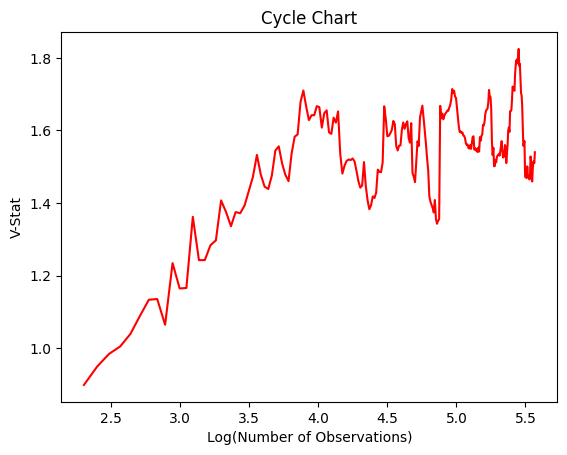

In [ ]:
plt.plot(log_obs, v_rs, "r-")
plt.xlabel("Log(Number of Observations)")
plt.ylabel("V-Stat")
plt.title("Cycle Chart")
plt.show()

In [ ]:
start = 37
sub_arr = np.array(v_rs[start:73])
time_index = np.argmax(sub_arr)
cycle_length = start + time_index
print(cycle_length)

39


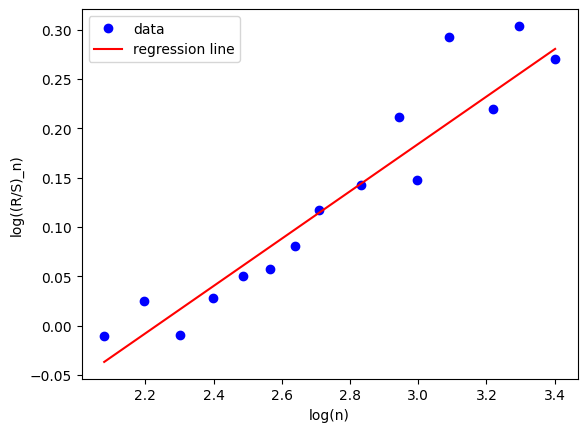

Hurst Exponent: 0.7401663588645696


In [ ]:
hurst_exponent = nolds.hurst_rs(data, debug_plot = True)
print(f"Hurst Exponent: {hurst_exponent}")

In [ ]:
!pip install git+https://github.com/manu-mannattil/nolitsa.git

  Cloning https://github.com/manu-mannattil/nolitsa.git to /tmp/pip-req-build-lc1m5tq6
  Running command git clone --filter=blob:none --quiet https://github.com/manu-mannattil/nolitsa.git /tmp/pip-req-build-lc1m5tq6
  Resolved https://github.com/manu-mannattil/nolitsa.git to commit ccd9fab08a88fbc6ff63f0fae28730ccb74754de
  Preparing metadata (setup.py) ... done
  Created wheel for nolitsa: filename=nolitsa-0.1-py3-none-any.whl size=22189 sha256=de10546f7925313655a899379bebda428d25234e64d6ba47fd38e2a06ed51c50
  Stored in directory: /tmp/pip-ephem-wheel-cache-gmbpvvsj/wheels/0e/f4/40/d6094caec491124c7302bf2741c9d0d9897bb655c18750e12c
Successfully built nolitsa


In [ ]:
import scipy
import numba
from nolitsa import dimension as ed

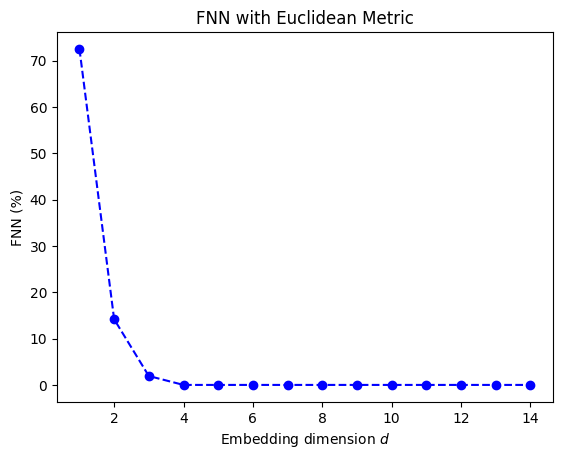

In [ ]:
dim = np.arange(1, 15, 1)
f1, f2, f3 = ed.fnn(data_price, tau=1, dim=dim, window=0, metric='euclidean')
plt.title(r'FNN with Euclidean Metric')
plt.xlabel(r'Embedding dimension $d$')
plt.ylabel(r'FNN (%)')
plt.plot(dim, 100 * f1, 'bo--', label=r'Test I')
#plt.plot(dim, 100 * f2, 'g^--', label=r'Test II')
#plt.plot(dim, 100 * f3, 'rs-', label=r'Test I + II')
#plt.legend()
plt.show()

In [ ]:
print(f1)

[0.72519084 0.14176245 0.01923077 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]


In [ ]:
t1, t2, t12 = ed.fnn(data)
embedding_dimension_float = t12 * 100
embedding_dimension = np.ceil(embedding_dimension_float)
embedding_dimension_int = int(embedding_dimension[0])
print(embedding_dimension_int)

94


In [ ]:
corr_dim = nolds.corr_dim(data_price, 4)
print(f"Correlation Dimension: {corr_dim}")

Correlation Dimension: 1.9309509099657993


In [ ]:
import statsmodels.api as sm

test_stat, p_value = sm.tsa.stattools.bds(data, max_dim = 4, epsilon = 0.7)
print(test_stat)
print(p_value)

[nan nan nan]
[nan nan nan]
